# 📘 Module 42 — Deep Learning Debugging
## Part 4: Practical Debugging — Revision Notes

The final section of Module 42 covers five practical debugging techniques: **inspect batches, inspect predictions, inspect gradients, check tensor shapes, and overfit a tiny dataset**. syllabus

---

# 1️⃣ Inspect Batches 📦🔍

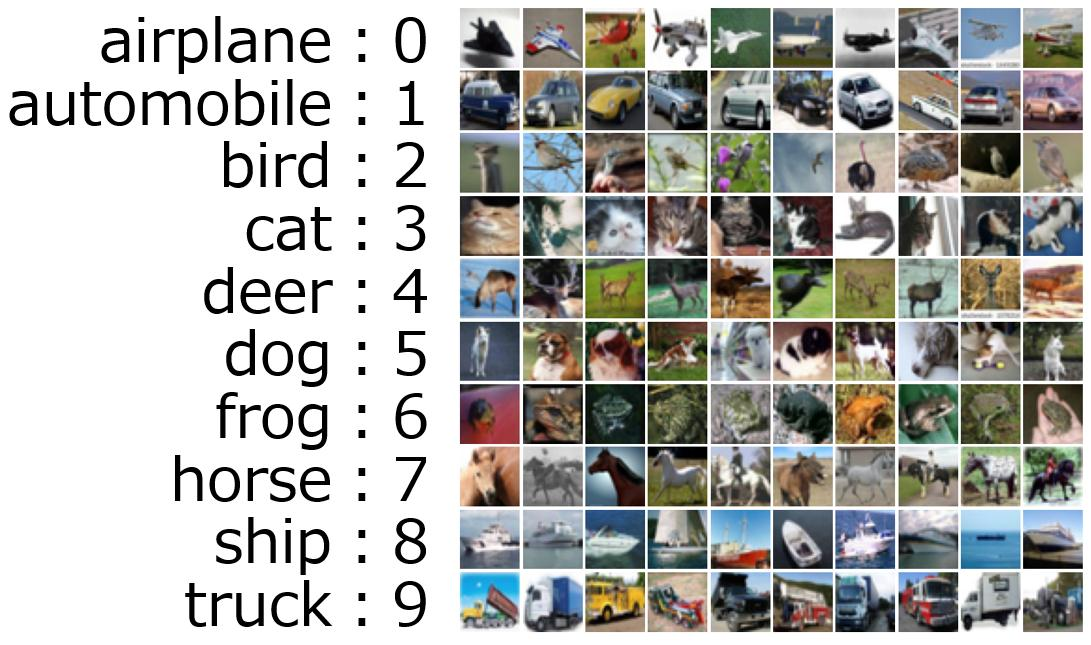

Before debugging the model, verify what the model is actually receiving.

```python
x, y = next(iter(train_loader))

print("Input:", x.shape)
print("Target:", y.shape)
print("Labels:", y)
```

For image data, **visualize the samples**.

```python
plt.imshow(x[0].permute(1, 2, 0))
plt.title(f"Label: {y[0].item()}")
plt.show()
```

### Check for:

- ❌ Wrong labels
- ❌ Incorrect normalization
- ❌ Unexpected dimensions
- ❌ Corrupted samples
- ❌ Incorrect class mapping

### 🧠 Rule

> **Verify the data before blaming the model.**

---

# 2️⃣ Inspect Predictions 🎯

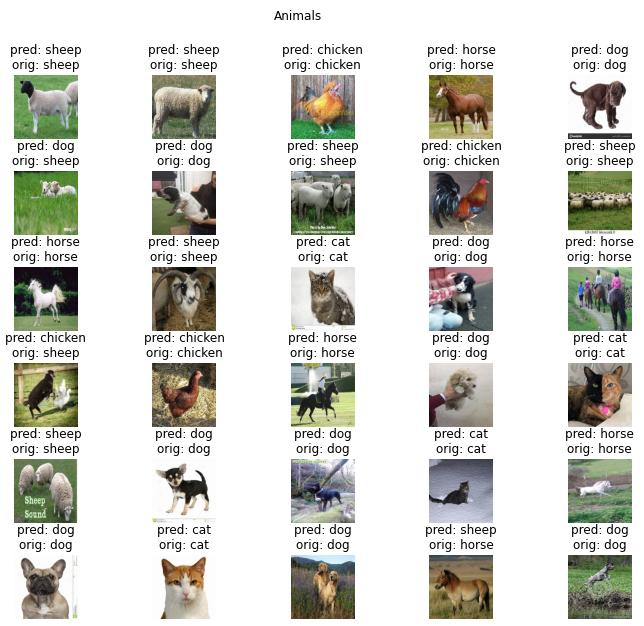

Look at **what the model actually predicts**.

For multiclass classification:

```python
with torch.no_grad():
    output = model(x)

predictions = output.argmax(dim=1)

print("Predicted:", predictions)
print("Actual:   ", y)
```

Example:

```text
Predicted: [2, 2, 2, 2, 2]
Actual:    [0, 1, 2, 1, 0]
```

This immediately tells you that the model may be behaving incorrectly.

### Look for patterns

```text
Everything → Class 0
```

Possible issues:

- Class imbalance
- Wrong labels
- Wrong loss
- Learning-rate problem
- Model/gradient problem

### 🧠 Rule

> **Don't only inspect the loss number. Inspect the predictions.**

---

# 3️⃣ Inspect Gradients 📊



After:

```python
loss.backward()
```

inspect the gradient magnitude:

```python
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())
```

### 💥 Very large gradients

```text
Layer 1 → 10
Layer 2 → 800
Layer 3 → 50000
```

Possible:

**Exploding gradients**

---

### 🫥 Very small gradients

```text
Layer 1 → 0.00000001
Layer 2 → 0.0000001
Layer 3 → 0.0001
```

Possible:

**Vanishing gradients**

---

### ⚠️ No gradient

```python
param.grad is None
```

Investigate whether that parameter is participating in the expected computation graph/training path.

---

# 4️⃣ Check Tensor Shapes 📐



For CNNs, a common image tensor format is:

```text
[B, C, H, W]
```

where:

- `B` → Batch size
- `C` → Channels
- `H` → Height
- `W` → Width

Always inspect:

```python
print("Input:", x.shape)

output = model(x)

print("Output:", output.shape)
print("Target:", y.shape)
```

### Shape debugging flow

```text
Input
 ↓
Intermediate tensors
 ↓
Model output
 ↓
Target
 ↓
Loss
```

### 🧠 Rule

> **Don't guess tensor shapes. Print them.**

---

# 5️⃣ Overfit a Tiny Dataset 🧪🔥



This is one of the most powerful debugging techniques.

Take a **tiny dataset**, such as 10 samples.

Then repeatedly train on those same samples.

```text
10 samples
    ↓
   Model
    ↓
Train repeatedly
    ↓
Can it memorize them?
```

### Expected result

Ideally:

```text
Loss       ↓↓↓
Accuracy   ↑↑↑
```

Eventually:

```text
Training accuracy ≈ 100%
```

---

## 🚨 If it cannot overfit 10 samples

There may be a fundamental problem:

```text
Can't overfit tiny dataset
          │
          ├── Wrong labels?
          ├── Wrong loss?
          ├── Wrong output shape?
          ├── Wrong activation?
          ├── Learning rate?
          ├── Gradient problem?
          └── Training-loop bug?
```

### Why this test works

You're temporarily removing the question:

> **"Can the model generalize?"**

and asking the simpler question:

> **"Can the model learn anything at all?"**

That's why the tiny-dataset test is so useful.

---

# 🔥 Complete Practical Debugging Checklist

| Step | Inspect | Main purpose |
|---|---|---|
| 1️⃣ | 📦 Batches | Verify data + labels |
| 2️⃣ | 🎯 Predictions | See actual model behavior |
| 3️⃣ | 📊 Gradients | Detect gradient problems |
| 4️⃣ | 📐 Tensor shapes | Find dimension mismatches |
| 5️⃣ | 🧪 Tiny dataset | Verify basic learning ability |

---

# 🧠 Debugging Order

```text
DATA
 ↓
TENSOR SHAPES
 ↓
MODEL OUTPUT
 ↓
PREDICTIONS
 ↓
LOSS
 ↓
GRADIENTS
 ↓
OPTIMIZER / LR
 ↓
TRAINING BEHAVIOR
 ↓
GENERALIZATION
```

This gives you a systematic approach instead of randomly changing hyperparameters.

---

# ⭐ Golden Debugging Test

> ### **Can I make the model overfit 10 samples?**

If **YES** ✅

→ The basic training pipeline is probably functioning.

If **NO** ❌

→ Investigate the fundamentals before attempting large-scale training.

---